# **Student Performance Indicator**

1. **Problem statement**

To understands how the student's performance is affected by other attirbutes like Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

2. **Data collection**

Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
The data consists of 8 column and 1000 rows.

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pradnya0510","key":"52d373de5764915440f36994ca1e2b1c"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d spscientist/students-performance-in-exams
!unzip students-performance-in-exams.zip

Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100% 8.70k/8.70k [00:00<00:00, 20.3MB/s]

Archive:  students-performance-in-exams.zip
  inflating: StudentsPerformance.csv  


**Import Data and Required Packages**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_df = pd.read_csv('StudentsPerformance.csv')
train_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


SHAPE OF DATASET

In [5]:
train_df.shape

(1000, 8)

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


STATISTICS OF DATASET

In [7]:
train_df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


-> The set doesn't contain missing values.



CHECK NO. OF UNIQUE ELEMENTS

In [8]:
train_df.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [9]:
train_df['gender'].unique()

array(['female', 'male'], dtype=object)

In [10]:
train_df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [11]:
train_df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [12]:
train_df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [13]:
train_df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [14]:
num_features = [feature for feature in train_df.columns if train_df[feature].dtype != 'O']
cat_features = [feature for feature in train_df.columns if train_df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(num_features), num_features))
print('\nWe have {} categorical features : {}'.format(len(cat_features), cat_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


CREATE NEW FEATURE AS TOTAL SCORE AND AVERAGE

In [15]:
train_df['total_score'] = train_df['math score'] + train_df['reading score'] + train_df['writing score']

In [16]:
train_df['avg'] = train_df['total_score']/3

In [17]:
train_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,avg
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [18]:
math_full = train_df[train_df['math score'] == 100]['avg'].count()
reading_full = train_df[train_df['reading score'] == 100]['avg'].count()
writing_full = train_df[train_df['writing score'] == 100]['avg'].count()
print("full marks in Math " + str(math_full))
print("full marks in Reading " + str(reading_full))
print("full marks in Writing " + str(writing_full))

full marks in Math 7
full marks in Reading 17
full marks in Writing 14


In [19]:
math_lessthan30 = train_df[train_df['math score'] < 30]['avg'].count()
reading_lessthan30 = train_df[train_df['reading score'] < 30]['avg'].count()
writing_lessthan30 = train_df[train_df['writing score'] < 30]['avg'].count()
print("less than 30 in Math " + str(math_lessthan30))
print("less than 30 in Reading " + str(reading_lessthan30))
print("less than 30 in Writing " + str(writing_lessthan30))

less than 30 in Math 14
less than 30 in Reading 8
less than 30 in Writing 9


-> Students have better performance in reading, followed by writing and then maths.

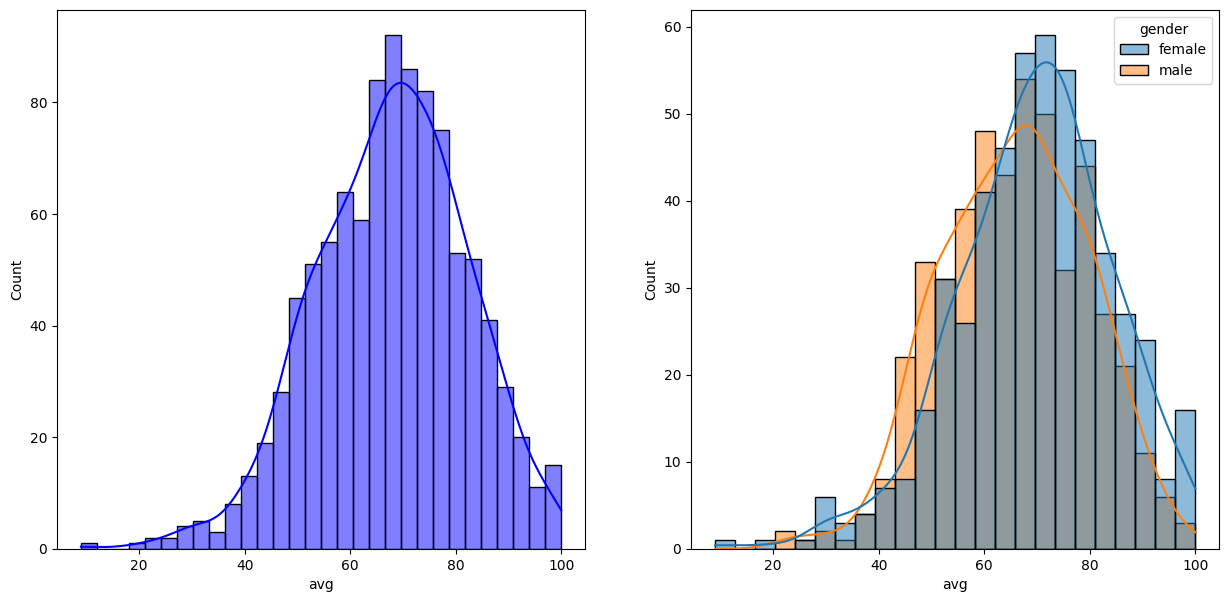

In [20]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=train_df,x='avg',bins=30,kde=True,color='b')
plt.subplot(1,2,2)
sns.histplot(data=train_df,x='avg',kde=True,hue='gender')
plt.show()

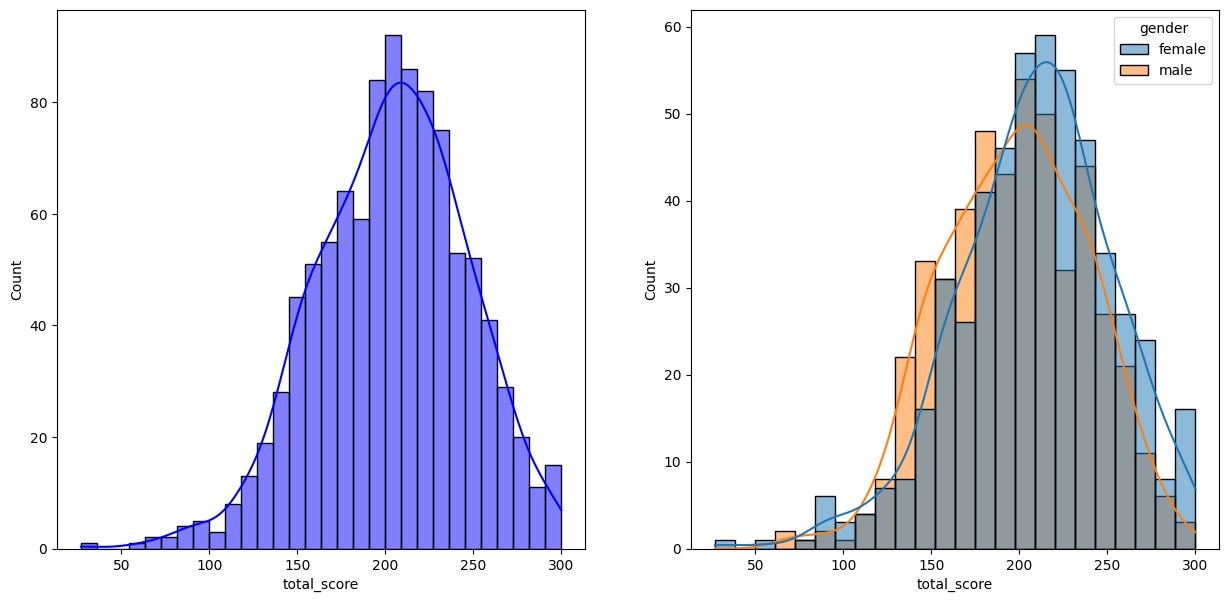

In [21]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=train_df,x='total_score',bins=30,kde=True,color='b')
plt.subplot(1,2,2)
sns.histplot(data=train_df,x='total_score',kde=True,hue='gender')
plt.show()

-> Female students perform better as compared to male students.

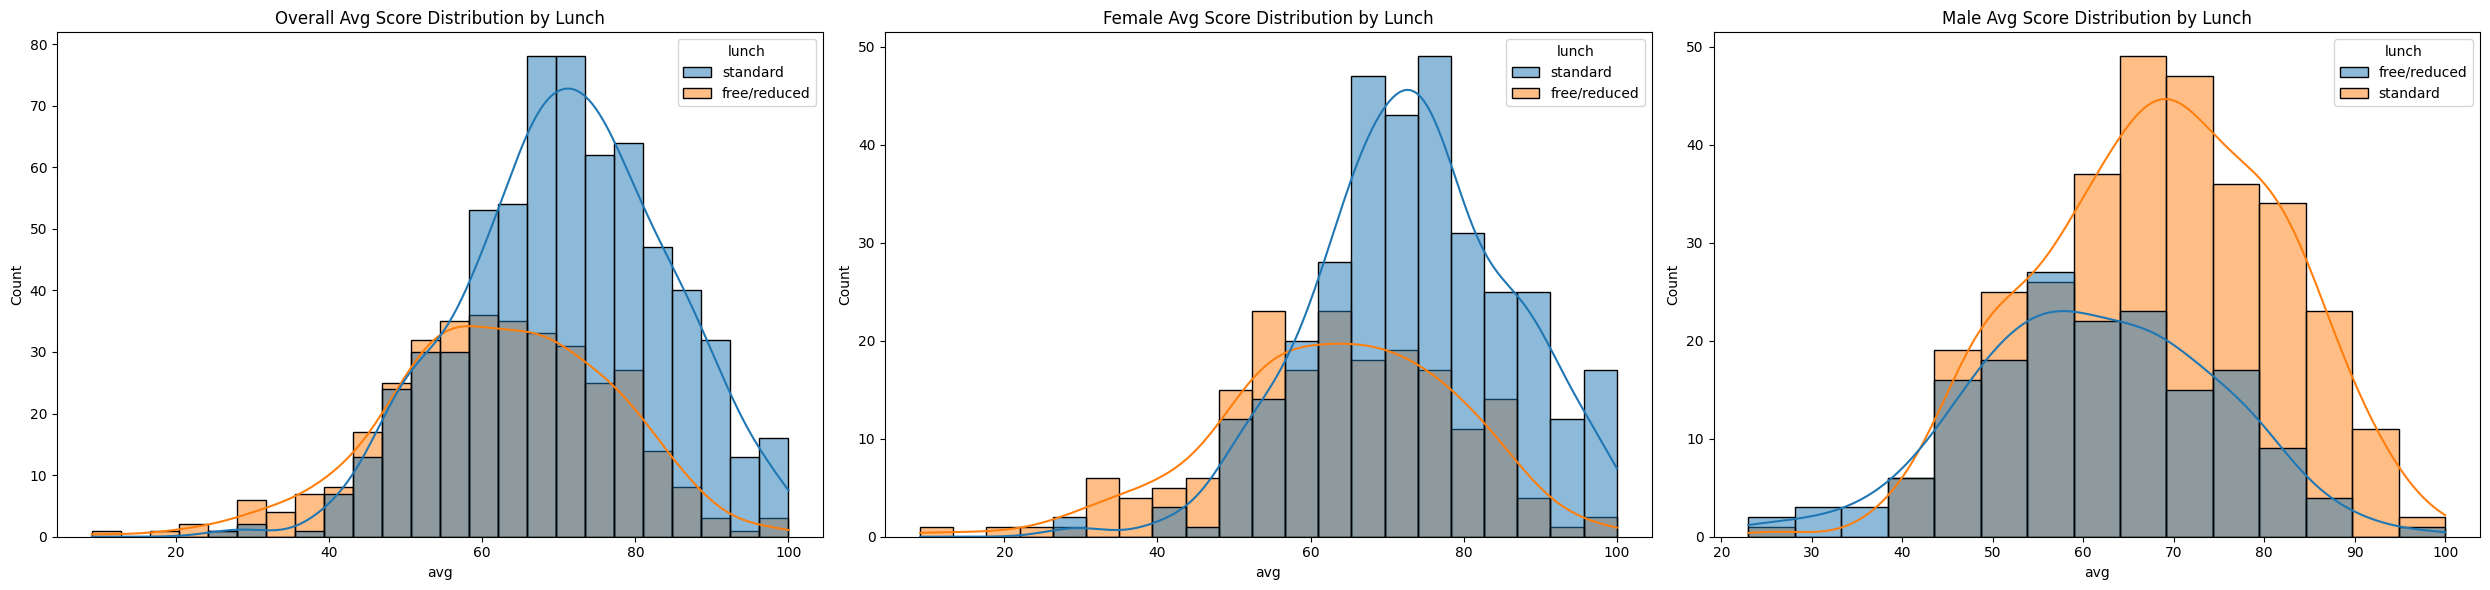

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=train_df, x='avg', kde=True, hue='lunch', ax=axes[0])
axes[0].set_title("Overall Avg Score Distribution by Lunch")

sns.histplot(
    data=train_df[train_df['gender'] == 'female'],
    x='avg',
    kde=True,
    hue='lunch',
    ax=axes[1]
)
axes[1].set_title("Female Avg Score Distribution by Lunch")

sns.histplot(
    data=train_df[train_df['gender'] == 'male'],
    x='avg',
    kde=True,
    hue='lunch',
    ax=axes[2]
)
axes[2].set_title("Male Avg Score Distribution by Lunch")

plt.tight_layout()
plt.show()

-> Overall, standard lunch is more benfitial in comparison to free/reduced lunch.<br> -> In case of average male distribution, free/reduced lunch seem to be helping genrously.

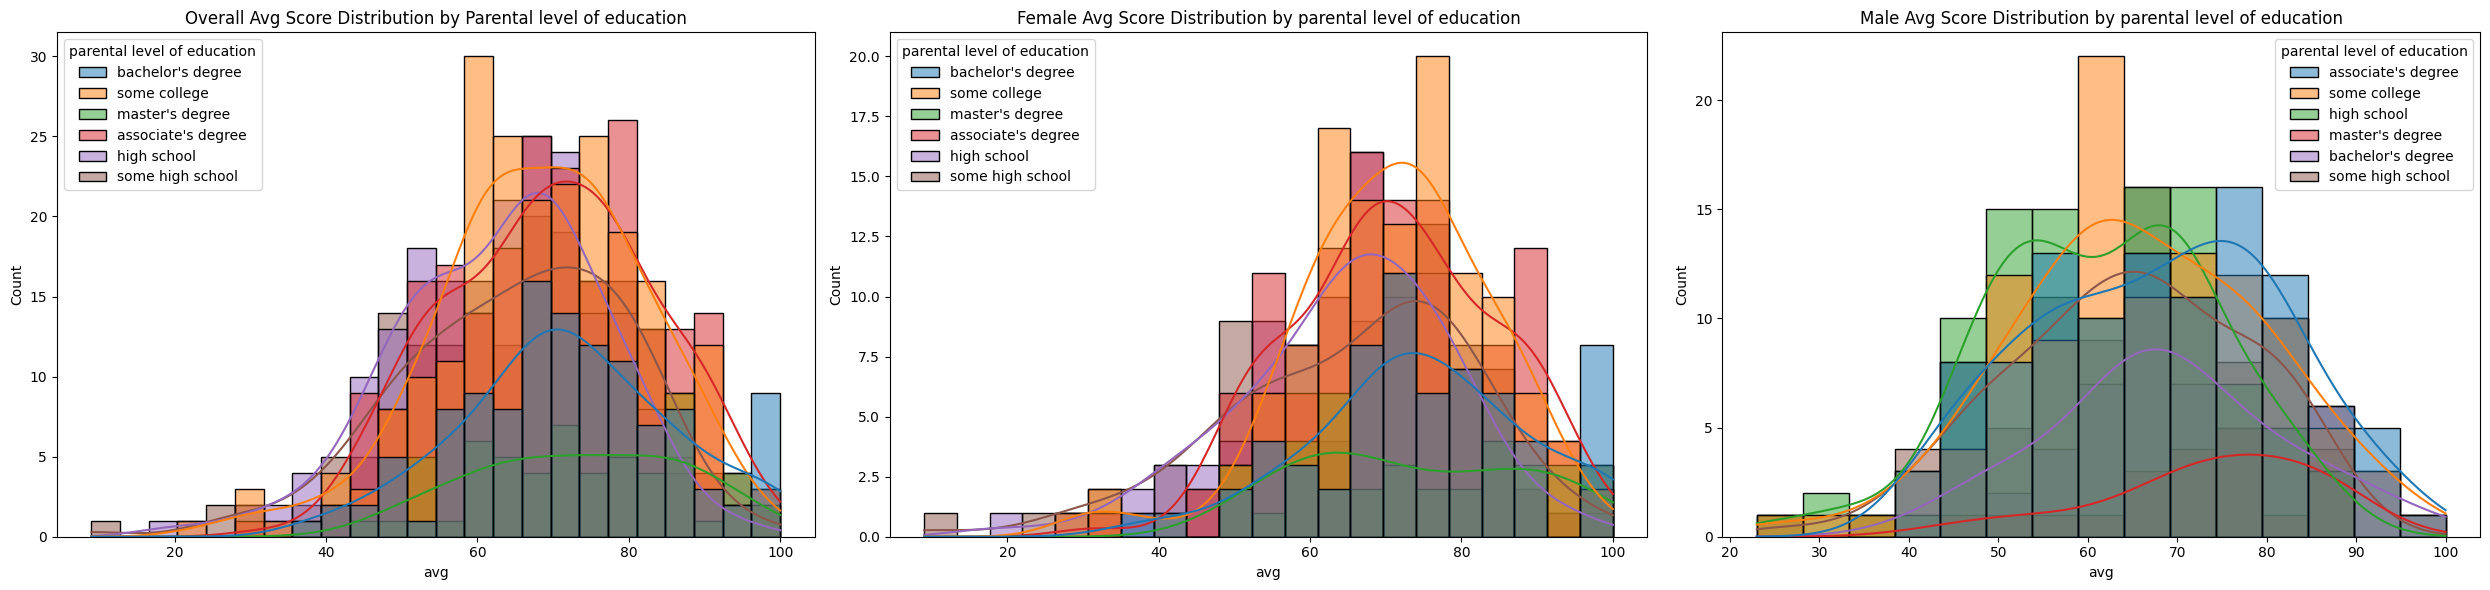

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=train_df, x='avg', kde=True, hue='parental level of education', ax=axes[0])
axes[0].set_title("Overall Avg Score Distribution by Parental level of education")

sns.histplot(
    data=train_df[train_df['gender'] == 'female'],
    x='avg',
    kde=True,
    hue='parental level of education',
    ax=axes[1]
)
axes[1].set_title("Female Avg Score Distribution by parental level of education")

sns.histplot(
    data=train_df[train_df['gender'] == 'male'],
    x='avg',
    kde=True,
    hue='parental level of education',
    ax=axes[2]
)
axes[2].set_title("Male Avg Score Distribution by parental level of education")

plt.tight_layout()
plt.show()

-> It is observed that the parental education doesnot help student's performance in general.

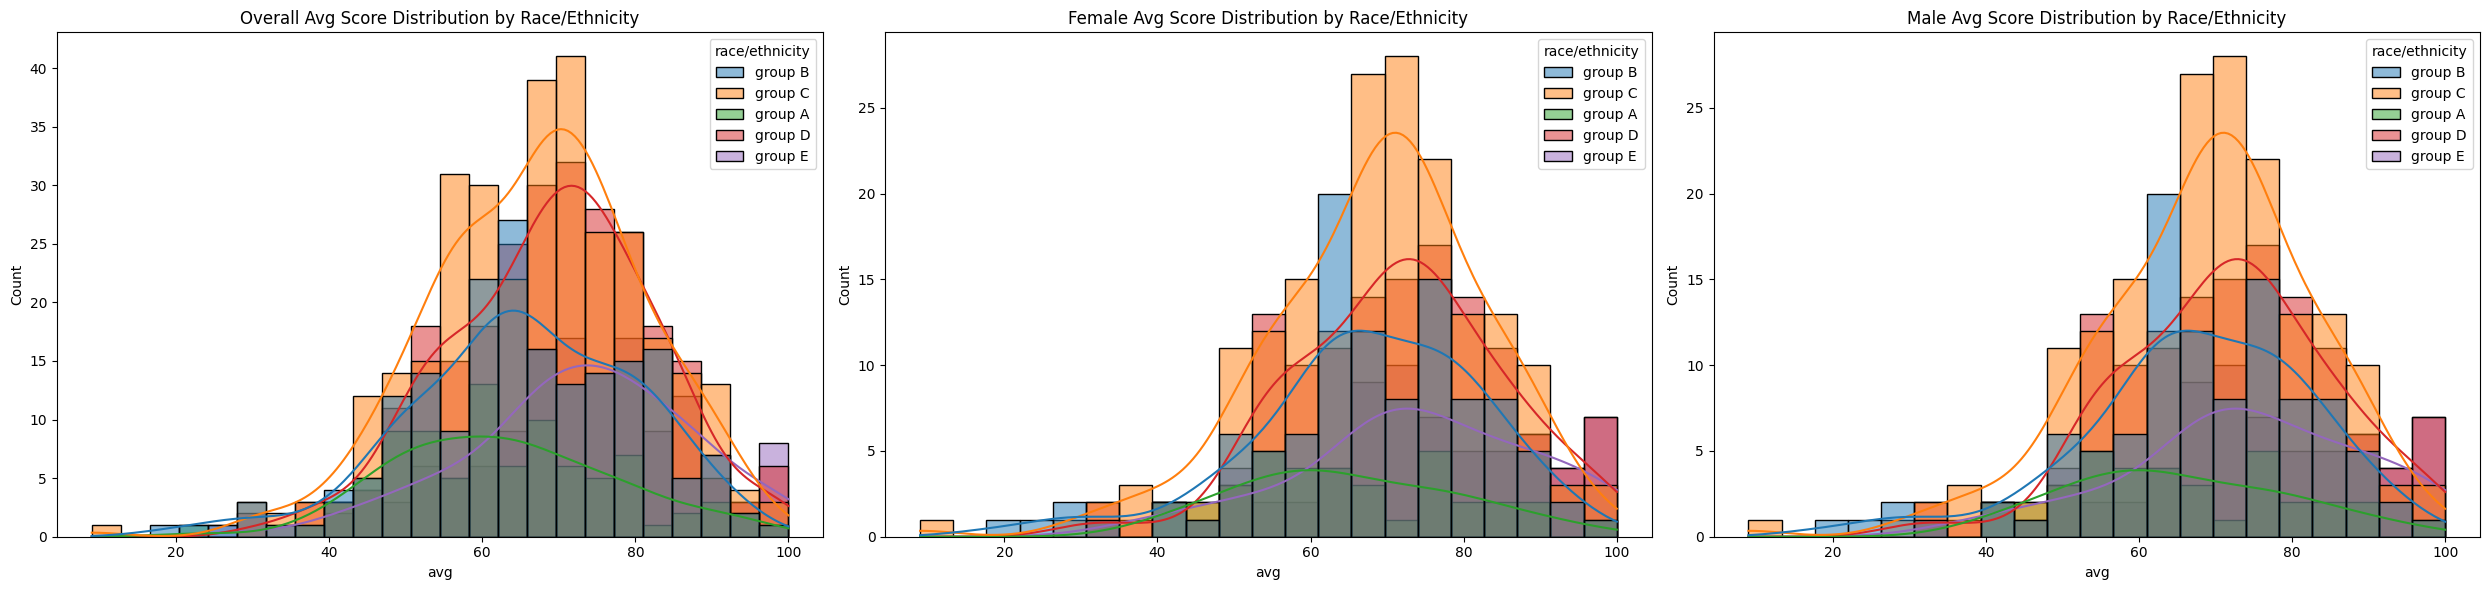

In [24]:
fig, axes = plt.subplots(1,3,figsize=(25,6))
sns.histplot(data=train_df,x='avg',kde=True,hue='race/ethnicity',ax=axes[0])
axes[0].set_title("Overall Avg Score Distribution by Race/Ethnicity")
sns.histplot(data=train_df[train_df['gender'] == 'female'],
             x='avg',
             kde=True,
             hue='race/ethnicity',
             ax=axes[1]
)
axes[1].set_title("Female Avg Score Distribution by Race/Ethnicity")
sns.histplot(data=train_df[train_df['gender'] == 'female'],
             x='avg',
             kde=True,
             hue='race/ethnicity',
             ax=axes[2])
axes[2].set_title("Male Avg Score Distribution by Race/Ethnicity")
plt.tight_layout()
plt.show()

-> Group C students perform better in exams irrespective of gender while in contrast group A student's perfomance is poor in exams.

MAXIMUM SCORE OF STUDENTS IN ALL 3 SUBJECTS

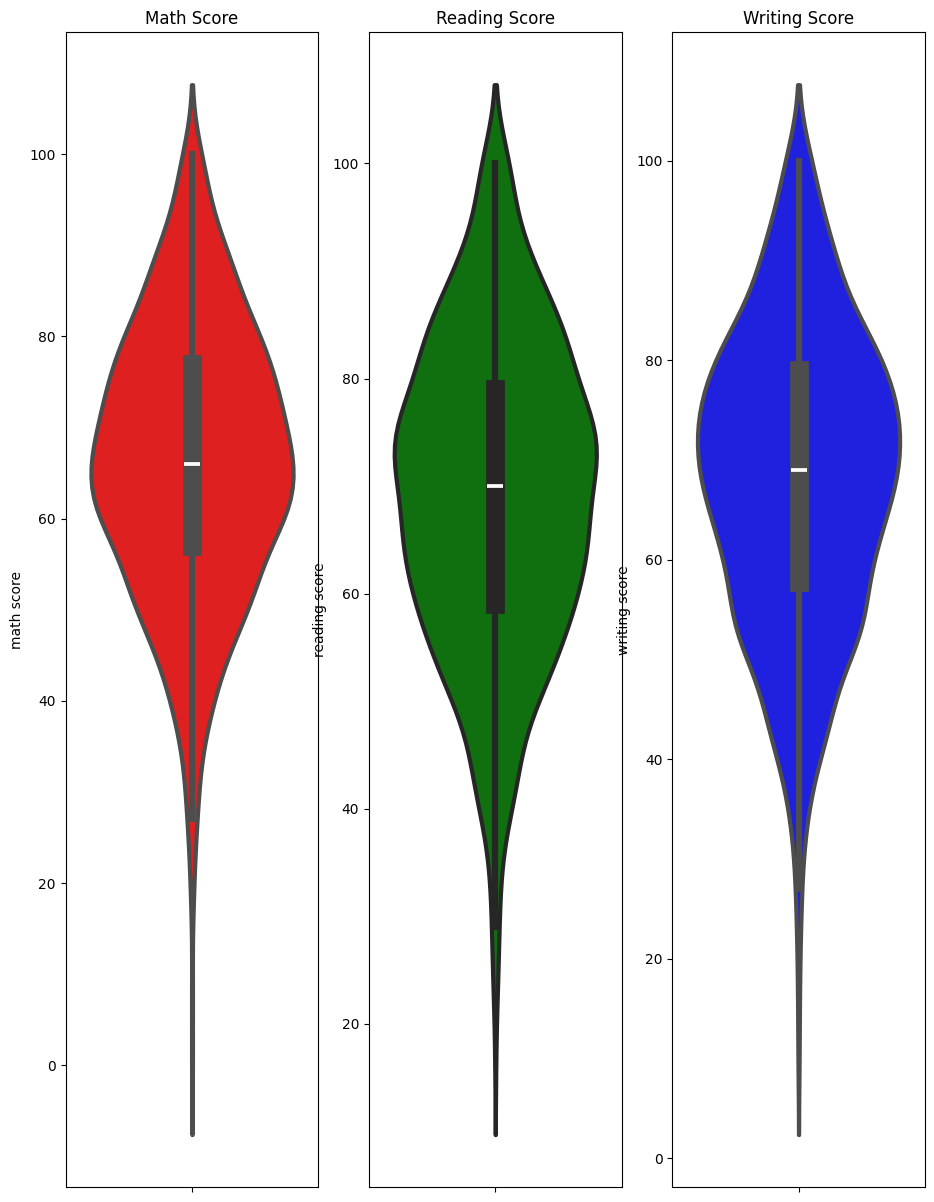

In [25]:
plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.title('Math Score')
sns.violinplot(y='math score',data=train_df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title('Reading Score')
sns.violinplot(y='reading score',data=train_df,color='green',linewidth=3)
plt.subplot(1,4,3)
plt.title('Writing Score')
sns.violinplot(y='writing score',data=train_df,color='blue',linewidth=3)
plt.show()

-> From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80.

MULTIVARIATE ANALYSIS USING PIEPLOT

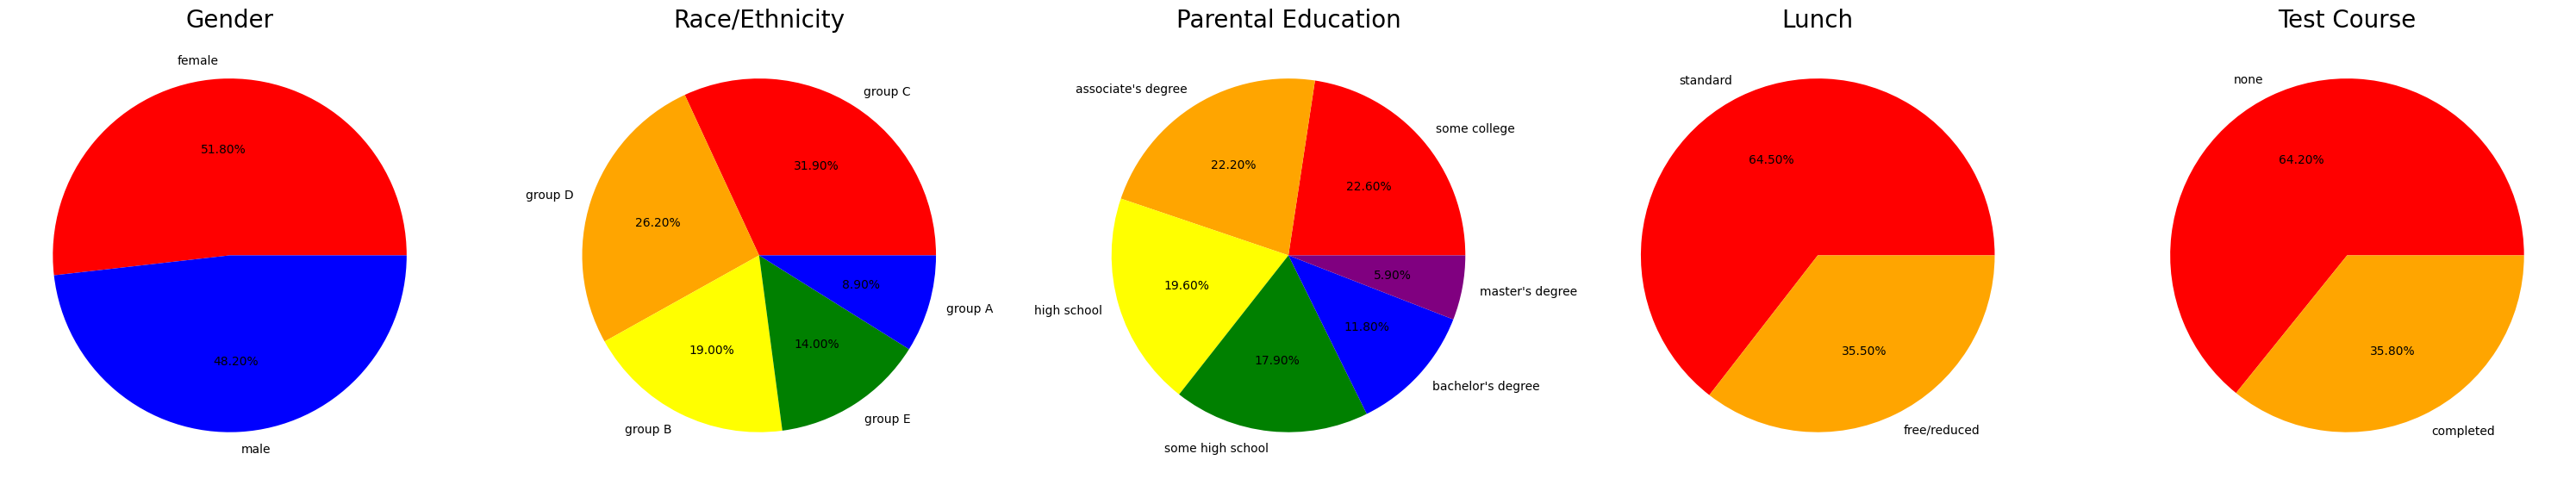

In [26]:
plt.rcParams['figure.figsize'] = (30,12)
plt.subplot(1,5,1)
size=train_df['gender'].value_counts()
labels='female','male'
color=['red','blue']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size=train_df['race/ethnicity'].value_counts()
labels=['group C','group D','group B','group E','group A']
color=['red','orange','yellow','green','blue']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title('Race/Ethnicity',fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size=train_df['parental level of education'].value_counts()
labels=['some college', 'associate\'s degree', 'high school', 'some high school', 'bachelor\'s degree', 'master\'s degree']
color=['red','orange','yellow','green','blue','purple']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title('Parental Education',fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size=train_df['lunch'].value_counts()
labels='standard','free/reduced'
color=['red','orange']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title('Lunch',fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size=train_df['test preparation course'].value_counts()
labels='none','completed'
color=['red','orange']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title('Test Course',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

-> The count of male and female students is almost same.<br> -> The number of students are highest in group C and lowest in group A of Race/Ethnicity.<br> -> The number of students with parental education of "some college" is more followed closely by "associate's degree".<br> -> Greater number of students have standard lunch. <br>-> Number of students who have not enrolled in any test preparation course is greater.

UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

/tmp/ipykernel_2691/3312763600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['gender'],data=train_df,palette='bright',ax=ax[0],saturation=0.95)


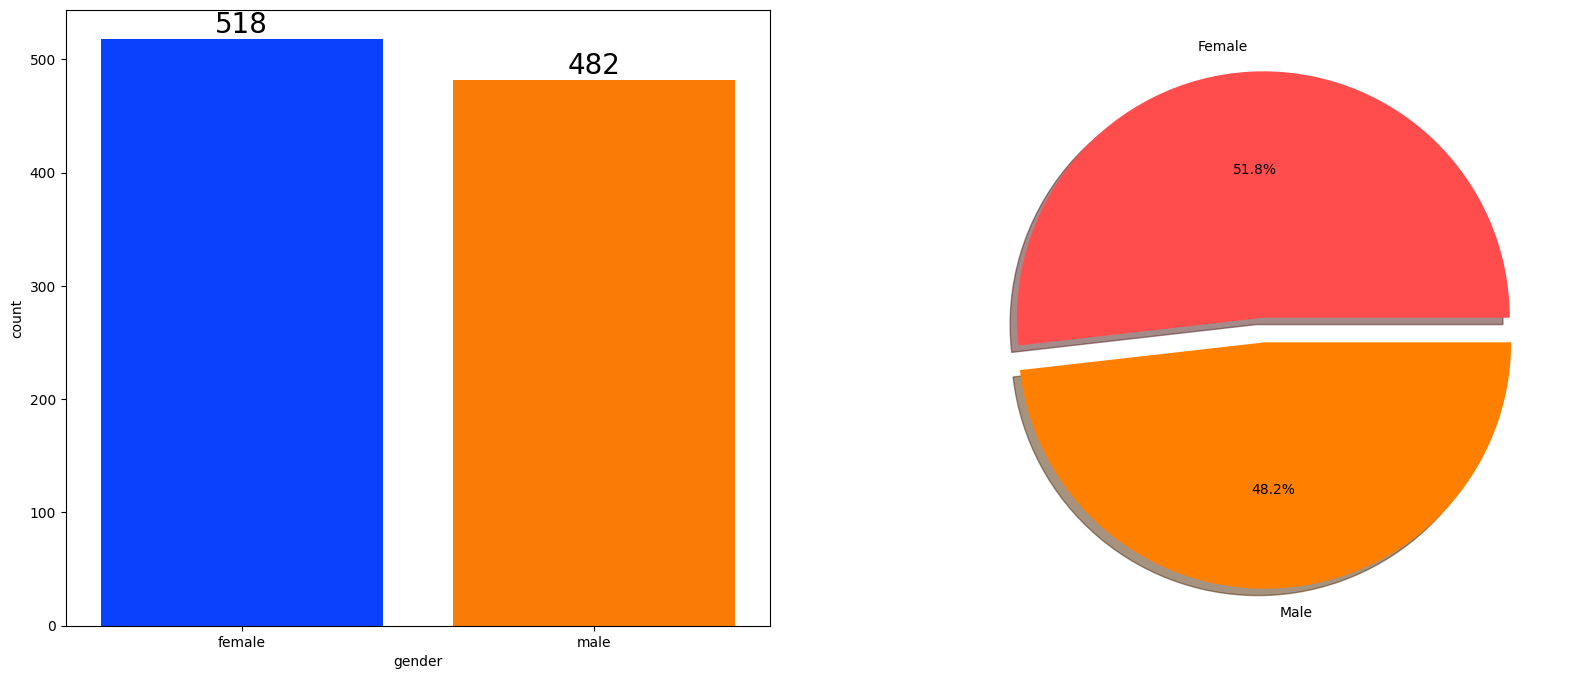

In [27]:
f,ax = plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=train_df['gender'],data=train_df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=train_df['gender'].value_counts(),labels=['Female','Male'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [28]:
gender_group = train_df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total_score,avg
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


/tmp/ipykernel_2691/2309101213.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y1 = [gender_group['avg'][1],gender_group['math score'][1]]
/tmp/ipykernel_2691/2309101213.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y2 = [gender_group['avg'][0],gender_group['math score'][0]]


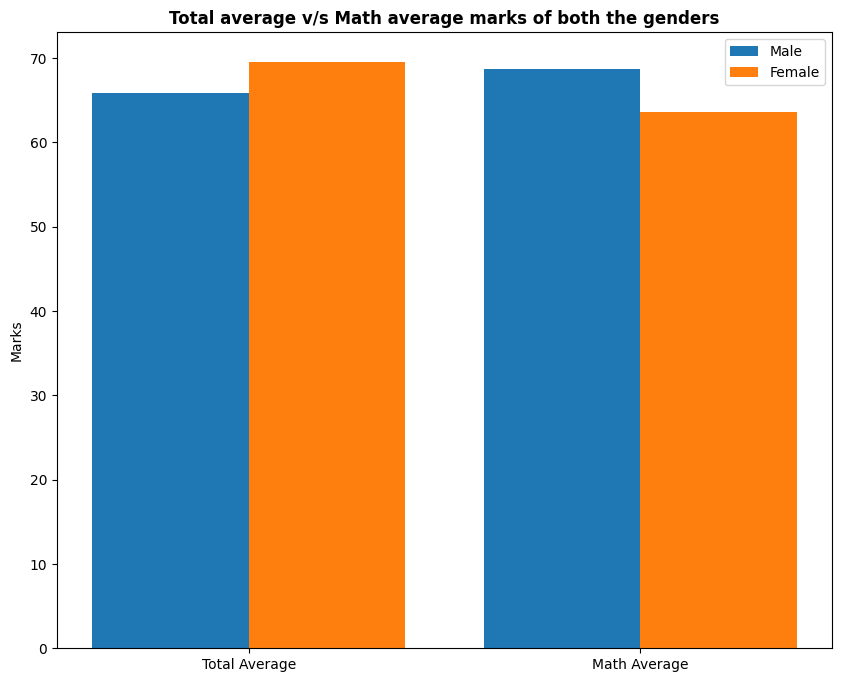

In [29]:
plt.figure(figsize=(10,8))

X = ['Total Average','Math Average']
Y1 = [gender_group['avg'][1],gender_group['math score'][1]]
Y2 = [gender_group['avg'][0],gender_group['math score'][0]]

X_axis = np.arange(len(X))

plt.bar(X_axis-0.2,Y1,0.4,label='Male')
plt.bar(X_axis+0.2,Y2,0.4,label='Female')

plt.xticks(X_axis,X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders",fontweight='bold')
plt.legend()
plt.show()

-> On an average, female students have better scores than the male students.<br> -> In Maths, male students have scored higher marks.

UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

/tmp/ipykernel_2691/2780435809.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['race/ethnicity'],data=train_df,palette='bright',ax=ax[0],saturation=0.95)


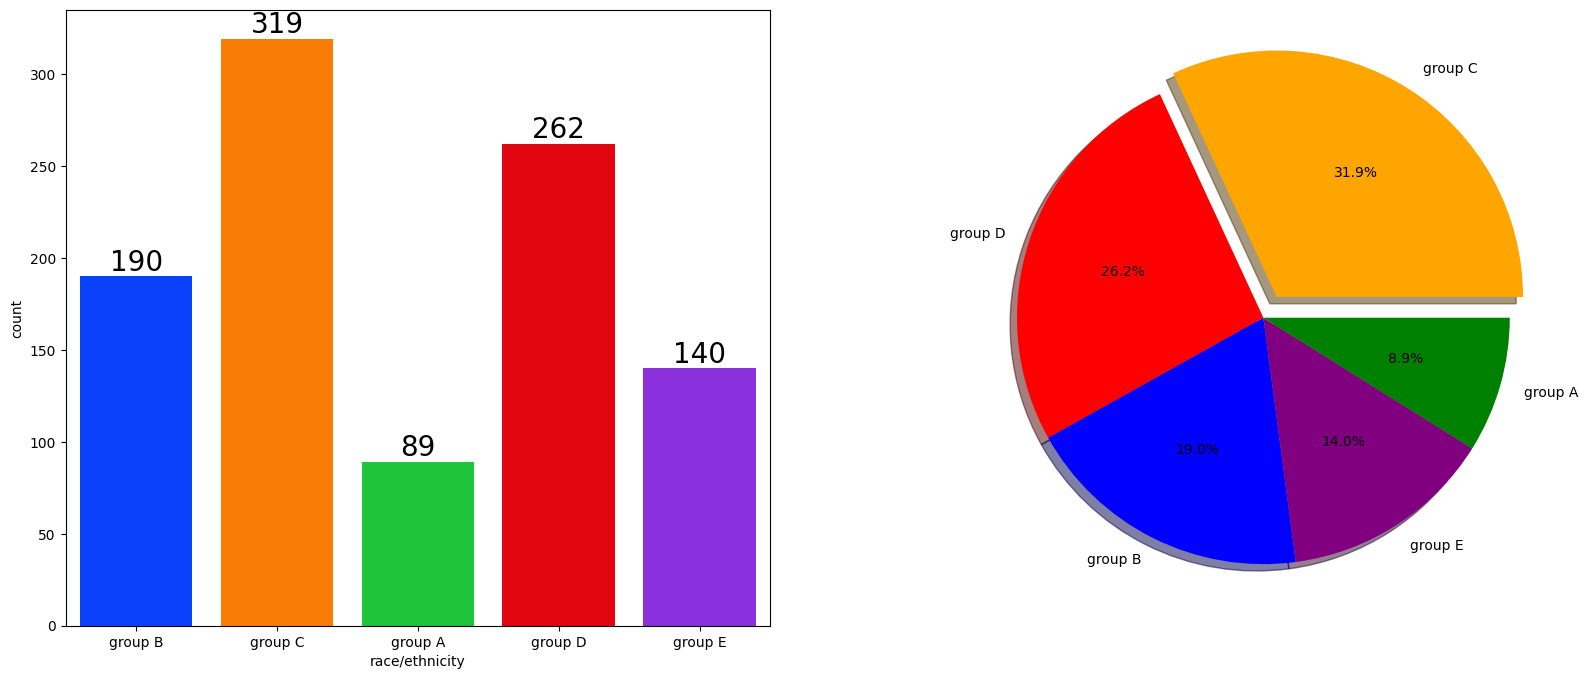

In [30]:
f,ax = plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=train_df['race/ethnicity'],data=train_df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

race_ethnicity_counts = train_df['race/ethnicity'].value_counts()
race_ethnicity_labels = race_ethnicity_counts.index.tolist()
race_ethnicity_explode = [0.1 if i == race_ethnicity_labels.index('group C') else 0 for i in range(len(race_ethnicity_labels))] # Explode 'group C'
race_ethnicity_colors = ['orange', 'red', 'blue', 'purple', 'green'] # Ensure 5 colors

plt.pie(x=race_ethnicity_counts,
        labels=race_ethnicity_labels,
        explode=race_ethnicity_explode,
        autopct='%1.1f%%',
        shadow=True,
        colors=race_ethnicity_colors)
plt.show()

BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

/tmp/ipykernel_2691/1605522028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_data2['math score'].mean().index,y=group_data2['math score'].mean().values,palette='spring',ax=ax[0])
/tmp/ipykernel_2691/1605522028.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_data2['reading score'].mean().index,y=group_data2['reading score'].mean().values,palette='summer',ax=ax[1])
/tmp/ipykernel_2691/1605522028.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_data2['writing score'].mean().index,y=group_data2['writing scor

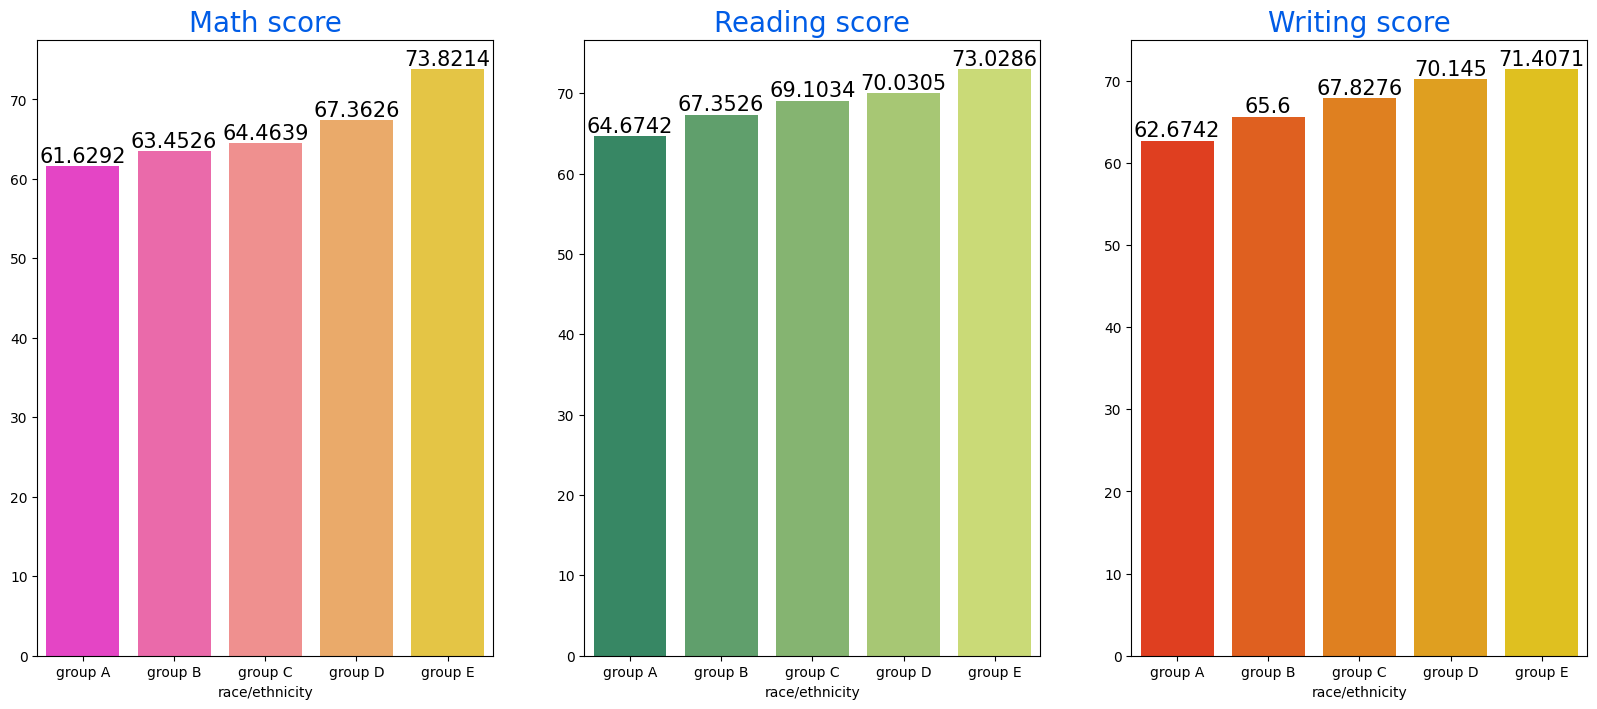

In [31]:
group_data2=train_df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=group_data2['math score'].mean().index,y=group_data2['math score'].mean().values,palette='spring',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=group_data2['reading score'].mean().index,y=group_data2['reading score'].mean().values,palette='summer',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=group_data2['writing score'].mean().index,y=group_data2['writing score'].mean().values,palette='autumn',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

->Group E students have scored highest marks.<br> -> Group A students have poor perfomnace in comparison to other race/enthnicities.

UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

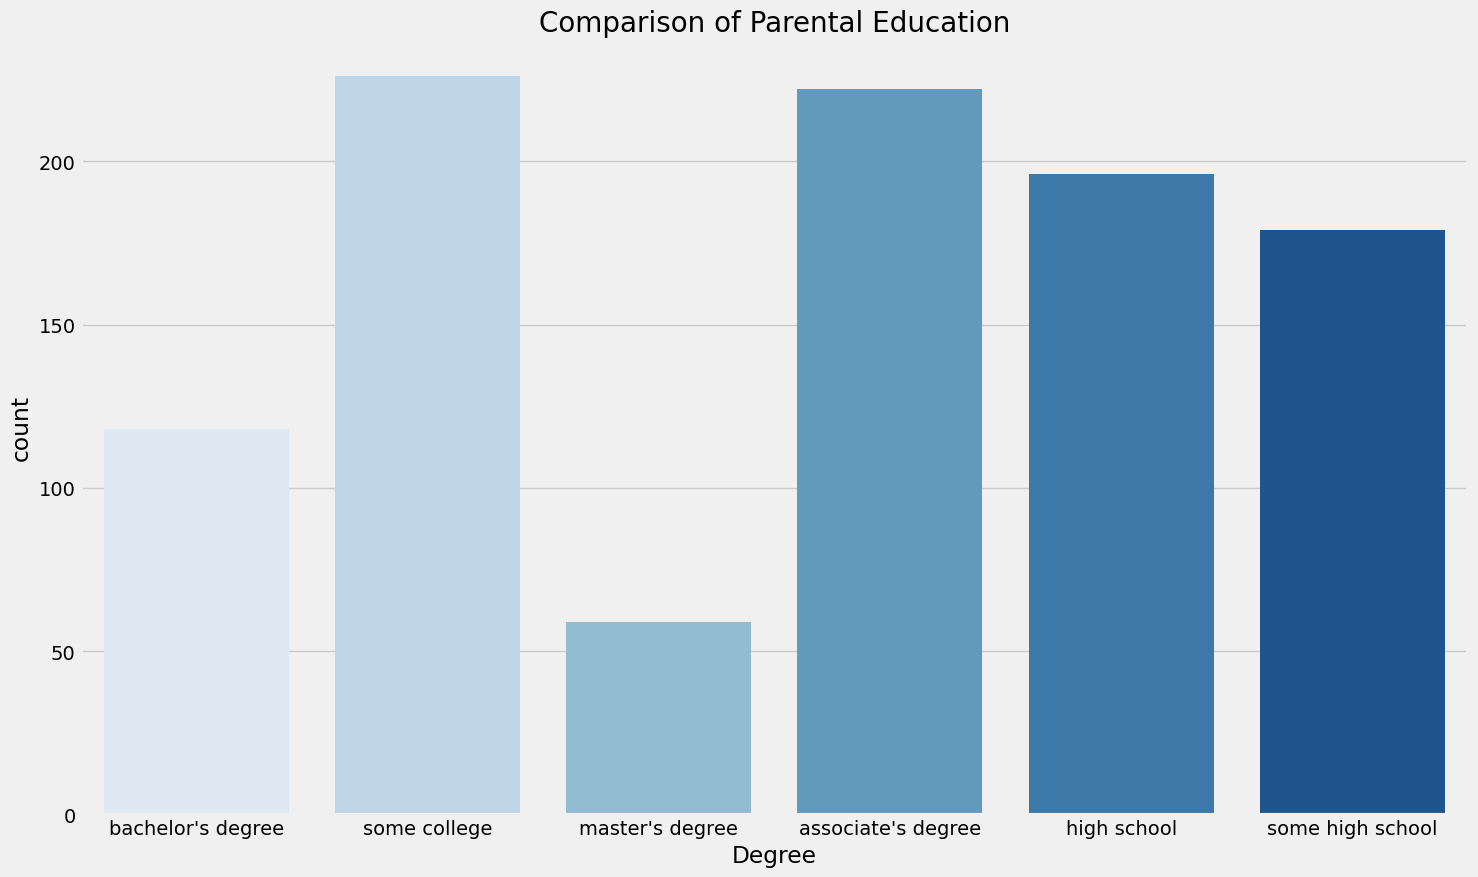

In [32]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(data=train_df, x='parental level of education', hue = 'parental level of education',palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.tight_layout()

plt.show()

BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

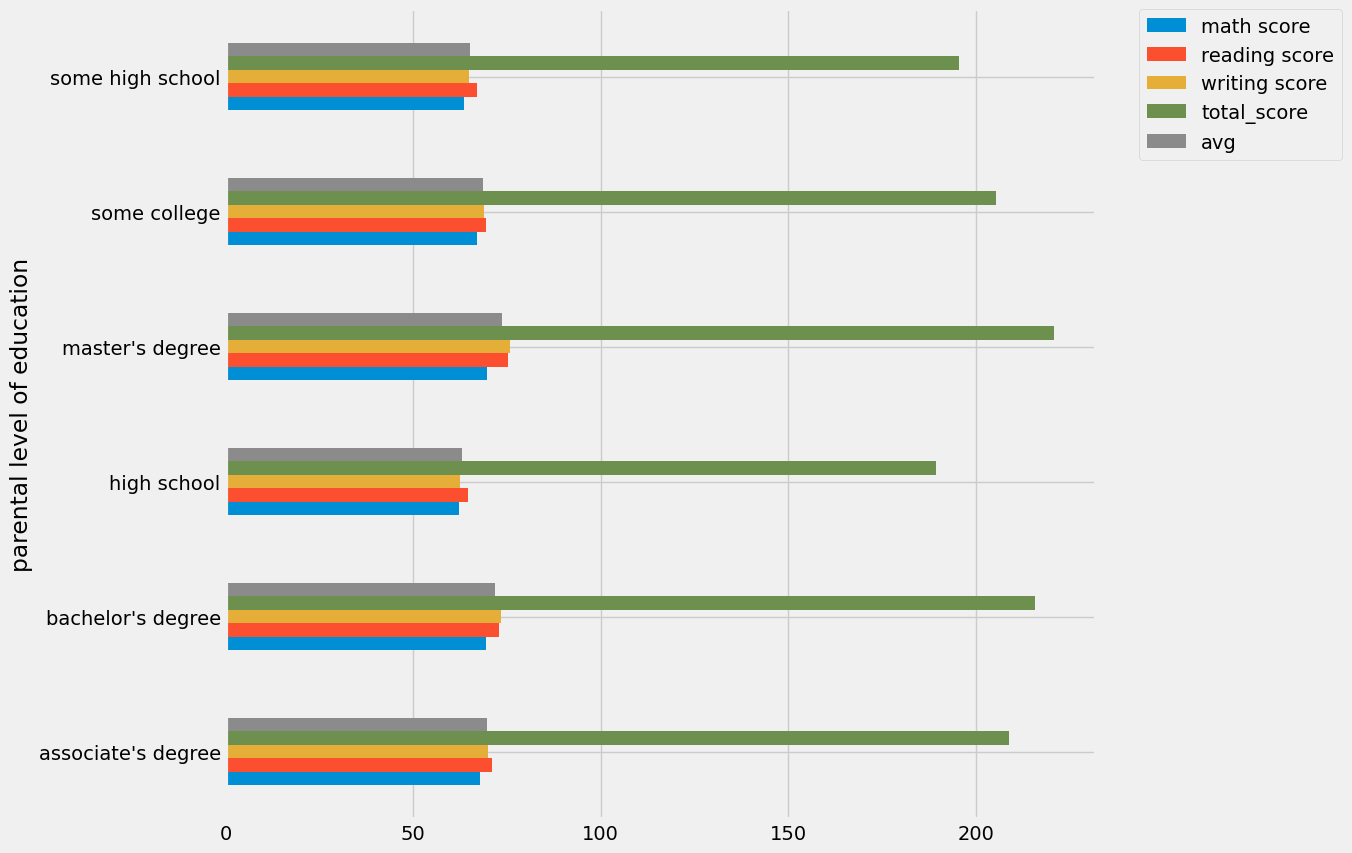

In [33]:
train_df.groupby('parental level of education').agg('mean', numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

-> The score of student whose parents possess master and bachelor level education are higher than others.


UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

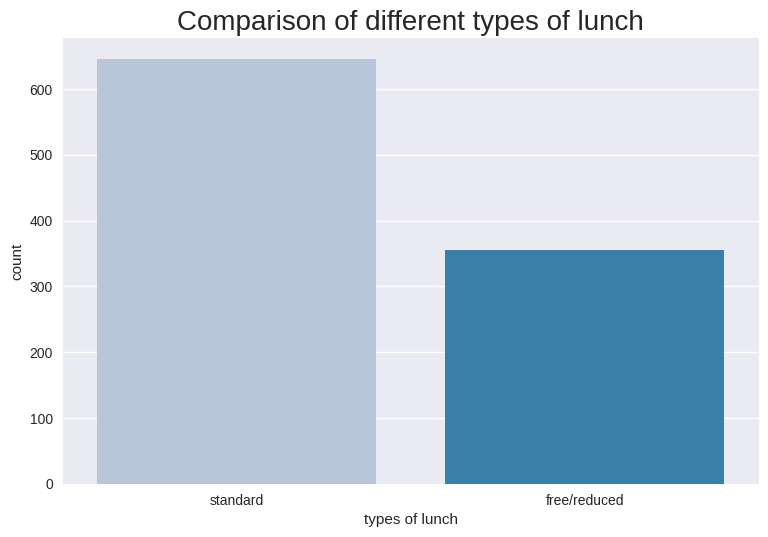

In [55]:
plt.rcParams['figure.figsize'] = (10, 9)
plt.style.use('seaborn-v0_8')
sns.countplot(data=train_df, x='lunch', hue='lunch',palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

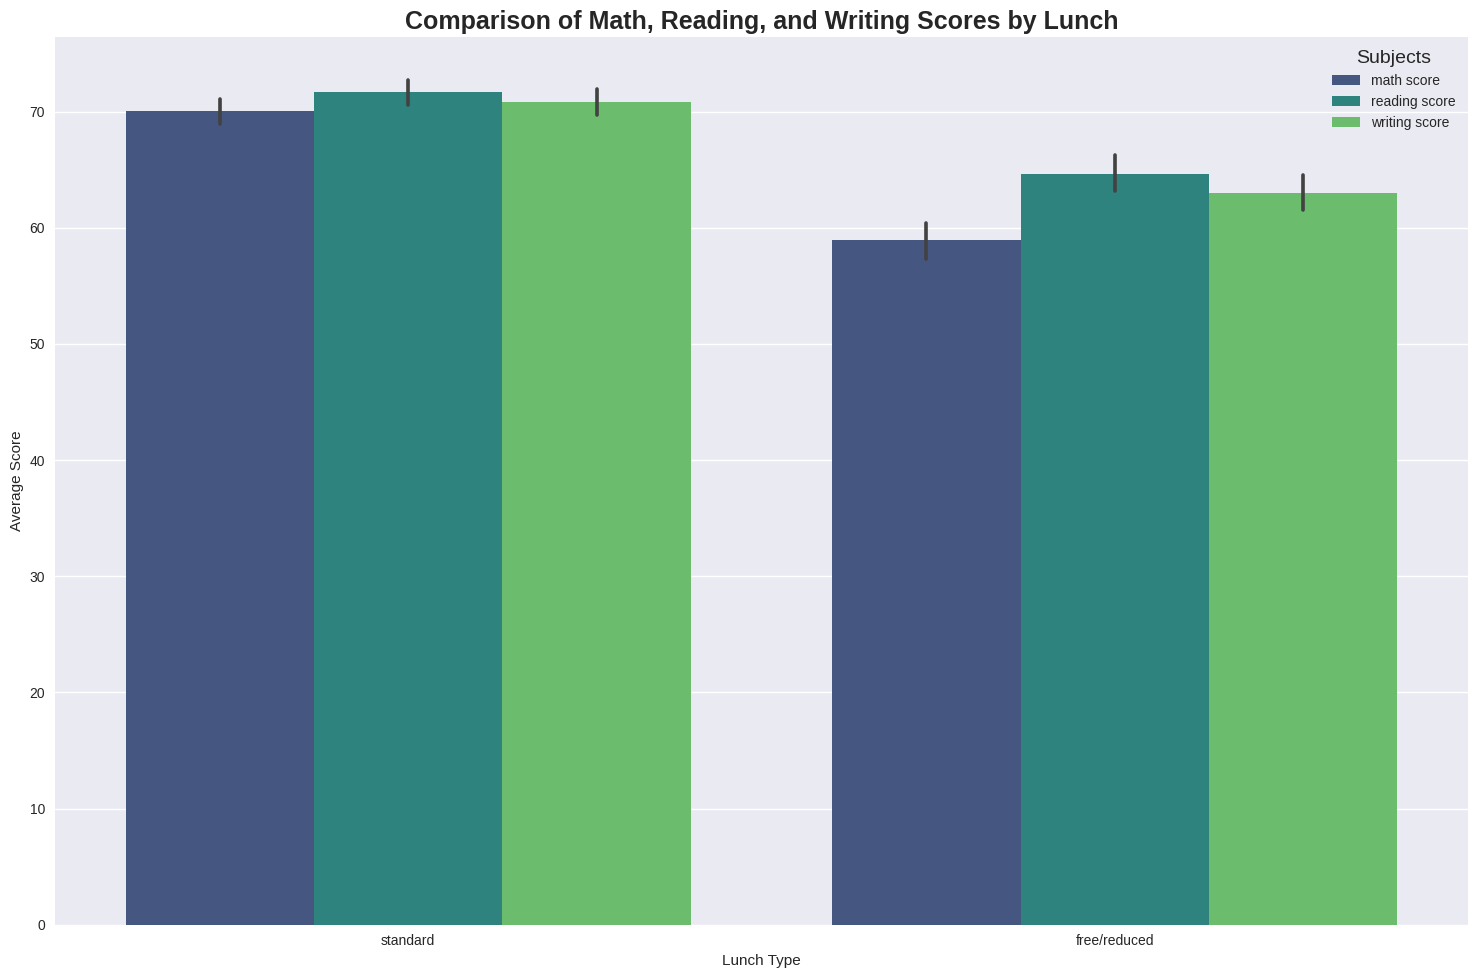

In [56]:
plt.figure(figsize=(15, 10))

score_df = train_df.melt(
    id_vars='lunch',
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='Subject',
    value_name='Score'
)

sns.barplot(
    data=score_df,
    x='lunch',
    y='Score',
    hue='Subject',
    palette='viridis'
)

plt.title('Comparison of Math, Reading, and Writing Scores by Lunch', fontsize=18, fontweight='bold')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.legend(title='Subjects')

plt.tight_layout()
plt.show()

-> It can be observed that the student perform better with Standard Lunch.

BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

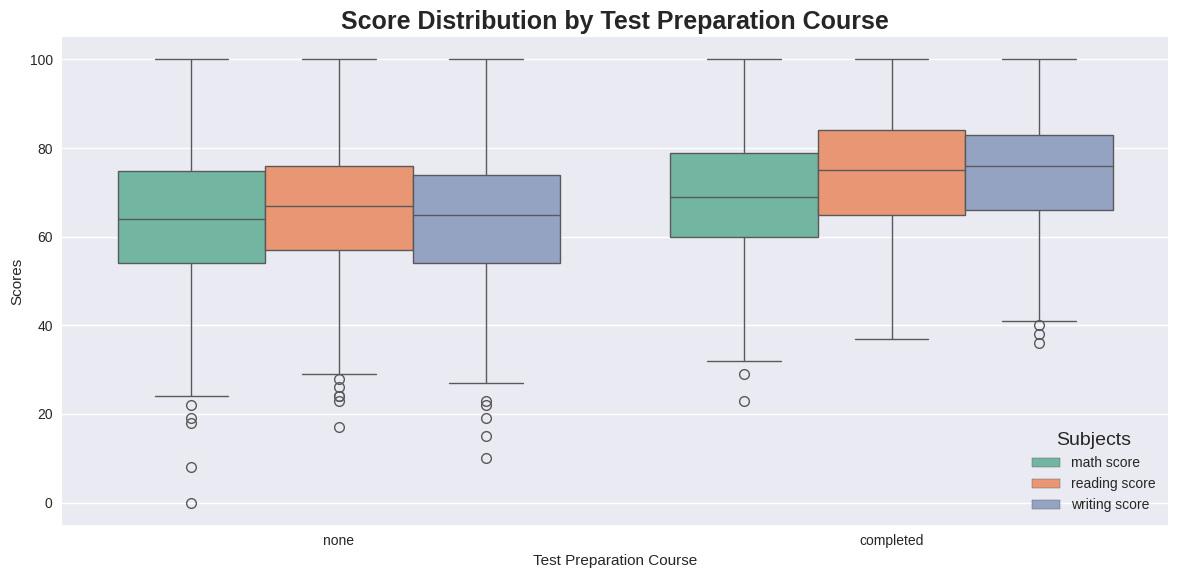

In [57]:
plt.figure(figsize=(12,6))
score_df = train_df.melt(
    id_vars='test preparation course',
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='Subject',
    value_name='Score'
)
sns.boxplot(
    data=score_df,
    x='test preparation course',
    y='Score',
    hue='Subject',
    palette='Set2'
)

plt.title('Score Distribution by Test Preparation Course', fontsize=18, fontweight='bold')
plt.xlabel('Test Preparation Course')
plt.ylabel('Scores')
plt.legend(title='Subjects')

plt.tight_layout()
plt.show()

-> Students with compeleted test preparation course have scored more than that of those who didn't take the preparation course.

CHECKING OUTLIERS

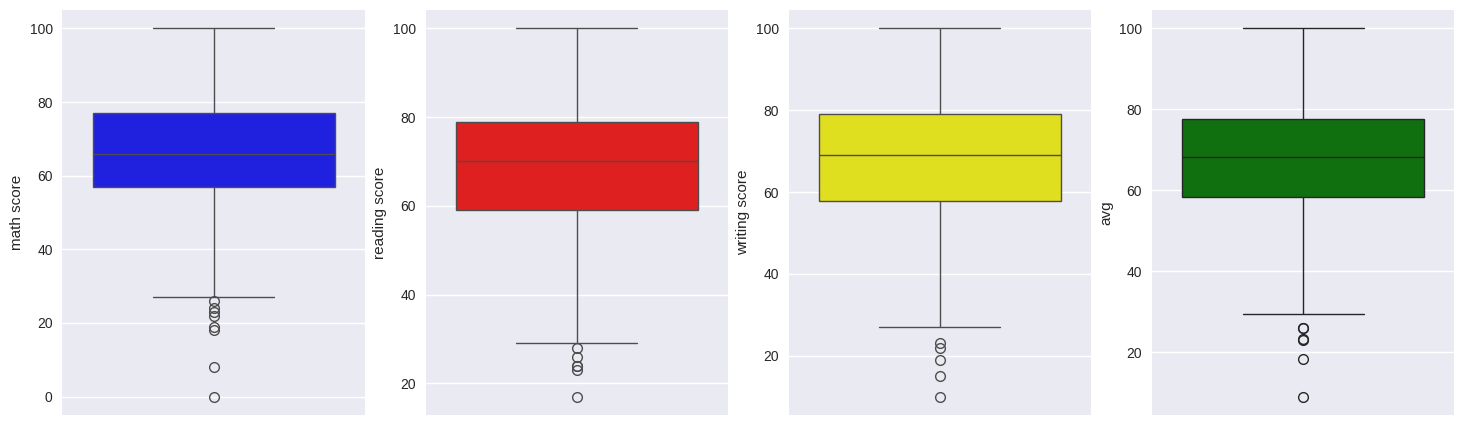

In [63]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(train_df['math score'],color='blue')
plt.subplot(142)
sns.boxplot(train_df['reading score'],color='red')
plt.subplot(143)
sns.boxplot(train_df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(train_df['avg'],color='green')
plt.show()

**CONCLUSION**

1. Student performance is heavily dependent on the attributes: gender, lunch, race/ethnicity, parrental level of education.
2. Female students perform better in comparison to male students.
3. Though test preparation course does not make much difference to student performance but it is observed that finishing test course is more benfitial.